**Introduction and Data Summary:**

For this project I worked with a heart disease dataset that includes features like age, cholesterol level, blood pressure, and heart rate I chose this dataset because it contains real-world medical data that can be useful for both analysis and prediction.

The goal of the clustering part was to group patients into similar categories based on their clinical features tthis helps in identifying different patient profiles such as high-risk vs low-risk groups 
the goal of the regression part was to predict cholesterol levels based on age to see if age could be a good indicator of cholesterol

In terms of application:
Clustering can be useful in healthcare for identifying patient segments that may require different types of care  For example, doctors could focus on clusters with older patients and high cholesterol for early intervention
- Regression could be used in medical prediction tasks, like estimating cholesterol when lab results are missing, or predicting future risk based on age and other factors.

Overall, this dataset allowed me to apply both clustering and regression techniques to explore patterns and draw meaningful insights from health data.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import silhouette_score
df = pd.read_csv(r'C:\Users\rahma\OneDrive - Kuwait University\Desktop\topics\heart_disease_cleaned.csv')

**clustering** 

In [27]:
clustering_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak','sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
available_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
print(f"Clustering features: {clustering_features}")
X_cluster = df[available_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(f"\nData prepared for clustering: {X_scaled.shape}")


Clustering features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Data prepared for clustering: (919, 5)


**• Determine the optimal number of clusters using the elbow or silhouette method.**


----------------------------------------
Finding optimal number of clusters...
----------------------------------------

Calculating silhouette scores...


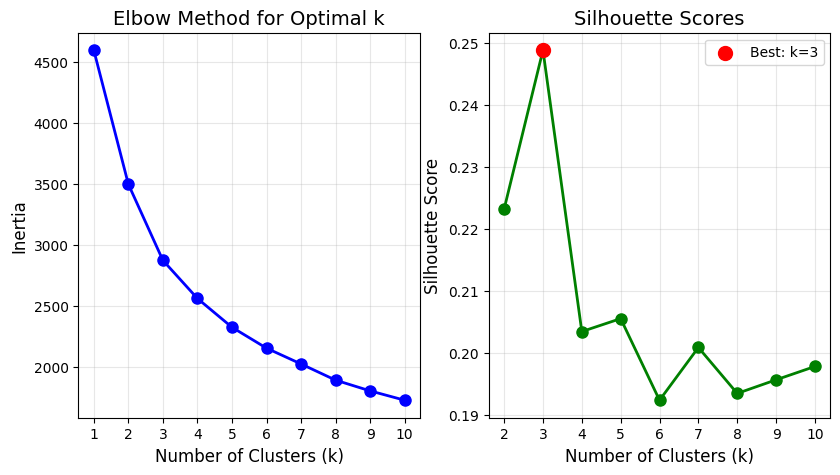

In [30]:
print("\n" + "-" * 40)
print("Finding optimal number of clusters...")
print("-" * 40)
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(15, 5))

# Plot 1: Elbow Method
plt.subplot(1, 3, 1)
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
# Add markers for potential elbow points
elbow_points = []
for i in range(1, len(inertias)-1):
    if inertias[i] - inertias[i+1] < (inertias[i-1] - inertias[i]) * 0.5:
        elbow_points.append(i+1)
        
if elbow_points:
    plt.scatter(elbow_points, [inertias[k-1] for k in elbow_points], 
                c='red', s=100, zorder=5, label=f'Elbow at k={elbow_points[0]}')
    plt.legend()
# Step 2: Calculate silhouette scores
print("\nCalculating silhouette scores...")
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Scores
plt.subplot(1, 3, 2)
plt.plot(range(2, 11), silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Scores', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(2, 11))
# Find best k based on silhouette score
best_k_silhouette = range(2, 11)[np.argmax(silhouette_scores)]
plt.scatter(best_k_silhouette, max(silhouette_scores), 
            c='red', s=100, zorder=5, 
            label=f'Best: k={best_k_silhouette}')
plt.legend()


**Apply k-Means**

In [33]:
# from the plots i can tell k=3
optimal_k=3
print(f"\nApplying K-Means clustering with k={optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = cluster_labels



Applying K-Means clustering with k=3...


In [35]:
# Analyze clusters
print("\n" + "-" * 40)
print("CLUSTER DISTRIBUTION")
print("-" * 40)
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Cluster {cluster_id}: {count} patients ({percentage:.1f}%)")


----------------------------------------
CLUSTER DISTRIBUTION
----------------------------------------
Cluster 0: 169 patients (18.4%)
Cluster 1: 391 patients (42.5%)
Cluster 2: 359 patients (39.1%)


**Visualize clusters (scatter plot, PCA projection, heatmaps)**


1. PCA Visualization (2D projection)...


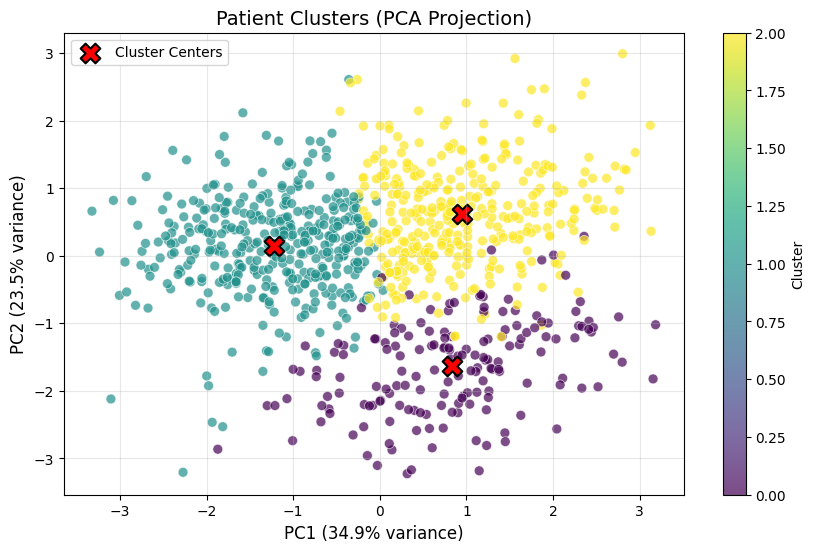

In [38]:
# PCA Projection (2D)
print("\n1. PCA Visualization (2D projection)...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],c=df['Cluster'],cmap='viridis',alpha=0.7, s=50, edgecolors='w', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Patient Clusters (PCA Projection)', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
# cluster centers
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            c='red', marker='X', s=200, label='Cluster Centers', 
            edgecolors='black', linewidth=1.5)
plt.legend()
plt.show()

The PCA helps reduce dimensions and makes it easier to visualize the separation between the groups from the plot we can see that the clusters are wellseparated meaning the K-means algorithm found meaningful groupings that supports the patterns different health profiles (age, cholesterol... etc.) likely drove this clustering


2. Cluster Characteristics Heatmap...


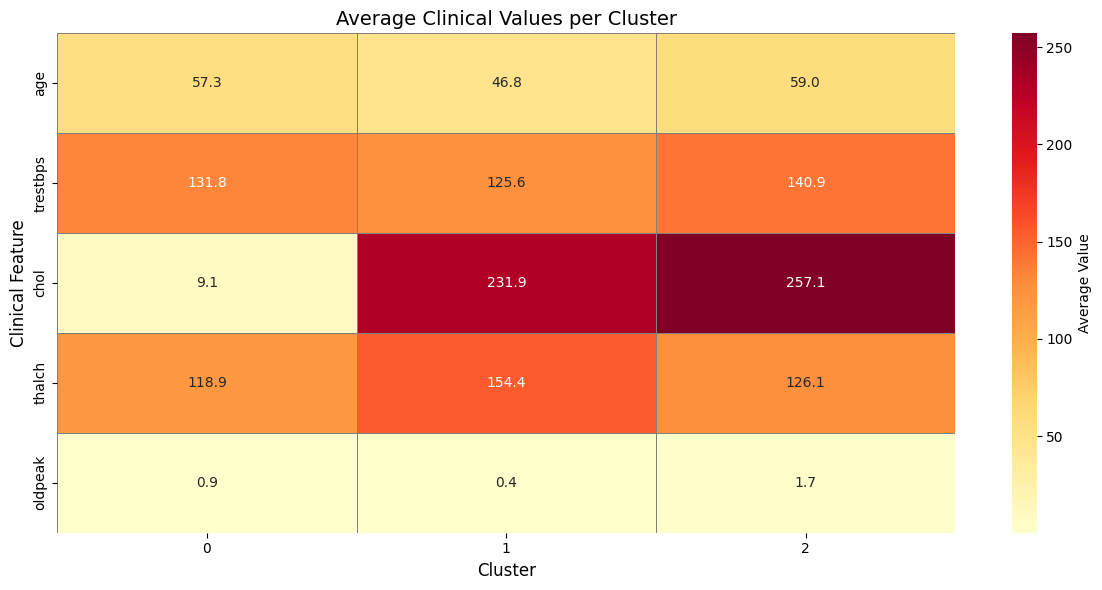

In [41]:
# Visualization 2: Cluster Statistics Heatmap
print("\n2. Cluster Characteristics Heatmap...")
cluster_stats = df.groupby('Cluster')[available_features].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_stats.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Average Value'})
plt.title('Average Clinical Values per Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
plt.tight_layout()
plt.show()


Cluster 0 has very low cholesterol (only 9.1) which seems like bad or missing data
Cluster 1 has younger patients with high max heart rate and moderate cholesterol.
Cluster 2 has older patients with the highest cholesterol highest resting BP and worst oldpeak 
Socluster 2 might include higher-risk patients

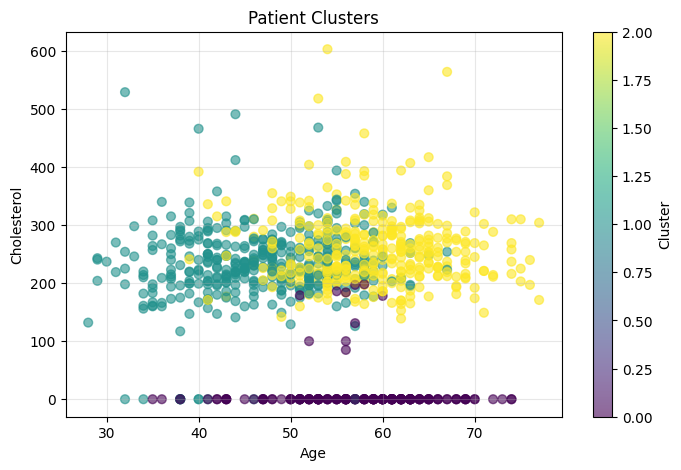

In [44]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['age'], df['chol'], c=df['Cluster'], cmap='viridis', alpha=0.6, s=40)
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Patient Clusters')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()


**INTERPRETATION AND PATTRENS**

Cluster 0 has older patients around 57 years old with moderate blood pressure and very low cholesterol which seems weird maybe there’s some missing or incorrect data their heart rate and heart strain (oldpeak) are moderate.

Cluster 1 is younger patients about 47 years old with lower blood pressure normal cholesterol levels higher heart rates, and low heart strain they seem like the healthier group

Cluster 2 is the oldest group, around 59 years old, with the highest blood pressure and cholesterol, moderate heart rates, and the highest heart strain these patients look like the highest risk group.

So overall the clusters split patients by age and heart health with cluster 2 being the group with the most concerning health signs

**REGGRESION**

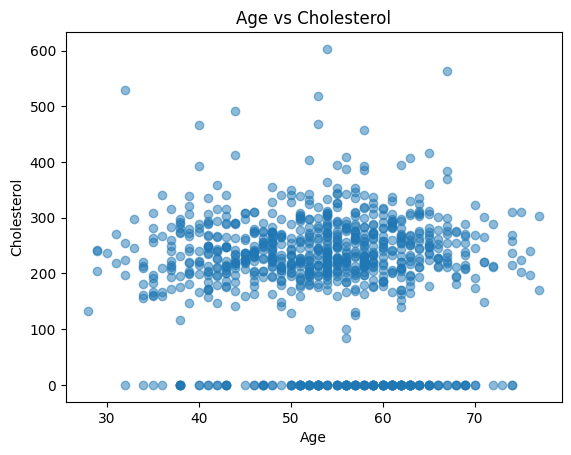

Correlation between age and cholesterol: -0.084


In [46]:
import matplotlib.pyplot as plt

plt.scatter(df['age'], df['chol'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Age vs Cholesterol')
plt.show()
corr = df['age'].corr(df['chol'])
print(f"Correlation between age and cholesterol: {corr:.3f}")

In [48]:
X_simple = df[['age']] 
y_simple = df['chol']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_simple = simple_model.predict(X_test_s)
r2_simple = r2_score(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
mae_simple = mean_absolute_error(y_test_s, y_pred_simple)
print(f"\nSimple Linear Regression: Predicting 'chol' from 'age'")
print(f"R² Score: {r2_simple:.4f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"MAE: {mae_simple:.2f}")
print(f"Coefficient: {simple_model.coef_[0]:.4f}")
print(f"Intercept: {simple_model.intercept_:.2f}")



Simple Linear Regression: Predicting 'chol' from 'age'
R² Score: 0.0046
RMSE: 108.13
MAE: 83.93
Coefficient: -1.0333
Intercept: 255.83


R² = 0.0046 
Very weak fit (explains less than 1% of variance).
RMSE (108.13) and MAE (83.93) 
High error in prediction.
Coefficient = -1.03 
Slight negative trend: as age increases cholesterol slightly decreases.
Intercept = 255.83 
When age is 0 predicted cholesterol is ~256 (not meaningful in reality).
age alone is a poor predictor of cholesterol in this dataset.

**===========================**

=========== SIMPLE LINEAR REGRESSION (AGE → CHOL) ===========
Coefficient: -1.0332734535170336
Intercept: 255.82623506279123
RMSE: 108.12789848797463
MAE: 83.93185498230704
R²: 0.004560489865902295


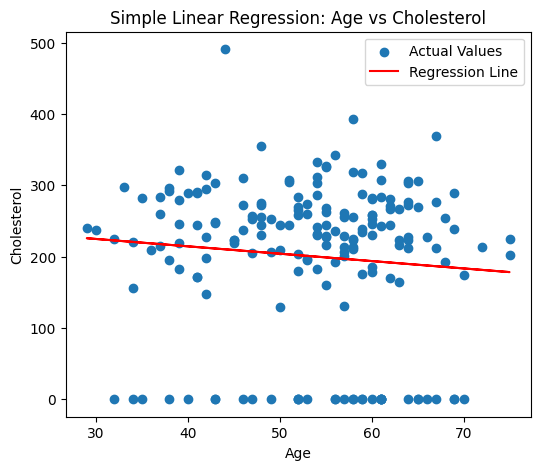

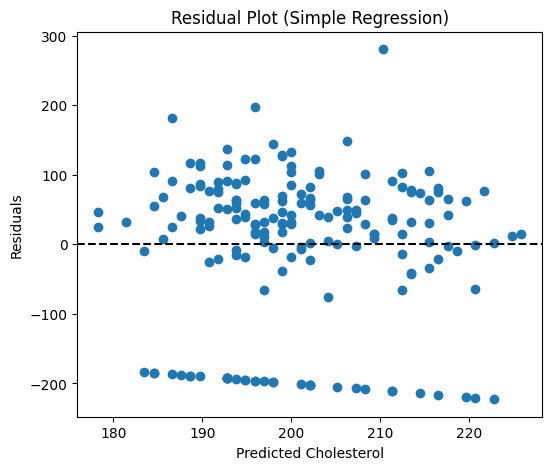

In [52]:
# =====================================================
# 1. SIMPLE LINEAR REGRESSION
# =====================================================
df_clean=df.copy()
X_simple = df_clean[['age']]
y = df_clean['chol']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_lr = LinearRegression()
simple_lr.fit(X_train_s, y_train_s)
y_pred_s = simple_lr.predict(X_test_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
mae_s = mean_absolute_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)
print("=========== SIMPLE LINEAR REGRESSION (AGE → CHOL) ===========")
print("Coefficient:", simple_lr.coef_[0])
print("Intercept:", simple_lr.intercept_)
print("RMSE:", rmse_s)
print("MAE:", mae_s)
print("R²:", r2_s)

# Plot: actual vs. predicted
plt.figure(figsize=(6,5))
plt.scatter(X_test_s, y_test_s, label="Actual Values")
plt.plot(X_test_s, y_pred_s, color="red", label="Regression Line")
plt.title("Simple Linear Regression: Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.legend()
plt.show()

# Residual plot
residuals_s = y_test_s - y_pred_s
plt.figure(figsize=(6,5))
plt.scatter(y_pred_s, residuals_s)
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Plot (Simple Regression)")
plt.xlabel("Predicted Cholesterol")
plt.ylabel("Residuals")
plt.show()


the red regression line is almost flat with a slight downward slope matching the small negative coefficient (-1.03)
the data points are widely scattered showing high variability and little alignment with the line


the residuals are widely spread above and below 0 indicating high prediction error
there is no clear pattern but we see a horizontal band of negative residuals around -200  likely from those 0 cholesterol values in the dataset


**• Interpret coe icients and model behavior.**

the regression coefficient is -1.03 meaning for every year increase in age cholesterol is predicted to decrease the intercept is 255.83 which is the predicted cholesterol when age is zero (not meaningful in practice but part of the equation)
The R² value is 0.0046 which means the model explains less than 1% of the variation in cholesterol so age is a very poor predictor

Overall the model shows a very weak slightly negative relationship between age and cholesterol and performs poorly The high RMSE and MAE also confirm that predictions are not accurate (age alome can't predict cholesterol)

**Overfitting and Model Comparison (Regression)**

**• Compare training vs. validation error when applicable**

In [55]:
# Predictions on training data
y_train_pred_s = simple_lr.predict(X_train_s)

# Training errors
train_rmse_s = np.sqrt(mean_squared_error(y_train_s, y_train_pred_s))
train_mae_s = mean_absolute_error(y_train_s, y_train_pred_s)

# Validation (test) errors already computed above
print("\n=========== TRAINING vs VALIDATION ERROR ===========")
print(f"Training RMSE: {train_rmse_s:.2f}")
print(f"Validation RMSE: {rmse_s:.2f}")
print(f"Training MAE: {train_mae_s:.2f}")
print(f"Validation MAE: {mae_s:.2f}")



=========== TRAINING vs VALIDATION ERROR ===========
Training RMSE: 108.93
Validation RMSE: 108.13
Training MAE: 81.58
Validation MAE: 83.93


The training and validation errors are very similar which tells me the model is not overfitting it's generalizing consistently across both datasets

However since both RMSE (~108) and MAE (~82) are quite high and the R² is low it confirms that this simple linear regression model doesn't perform well overall age alone just isn't a strong predictor of cholesterol in this case

**Identify signs of overfitting using residuals** 

In [61]:
# Residual statistics
print("\n=========== RESIDUAL ANALYSIS ===========")
print(f"Mean of residuals: {residuals_s.mean():.4f}")
print(f"Std of residuals: {residuals_s.std():.2f}")


=========== RESIDUAL ANALYSIS ===========
Mean of residuals: 1.2728
Std of residuals: 108.42


Mean of residuals: 1.27 
this is very close to 0 which is good it means the model isn't biased overall (no strong over or underprediction on average)
Standard deviation: 108.42 
this is high showing that the residuals (errors) vary a lot the predictions are not close to actual values for many points
the model is unbiased but the predictions are inaccurate and inconsistent again showing that age is not a good predictor of cholesterol

**OVERFIT**

there was no overfit in my model so i didn't need to do anything but here are some ways to reduce over fitting 
1. Use K-Fold Cross Validation
2. Use fewer features (simpler model)
3. Add regularization (Ridge or Lasso)
4. Remove noisy or irrelevant variables

**Visualization and Insights**

**CLUSTERING**

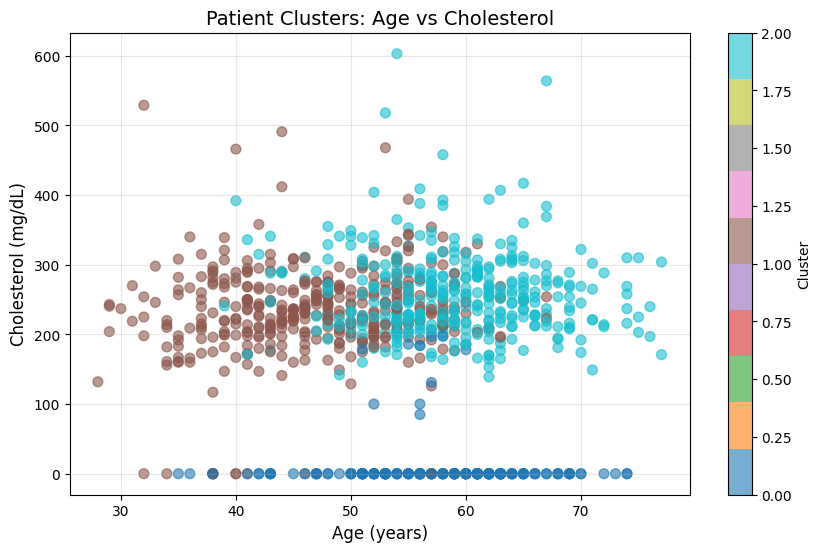

In [78]:
# Plot 1: Cluster Scatter Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['age'], df['chol'], c=df['Cluster'], 
                      cmap='tab10', alpha=0.6, s=50)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Cholesterol (mg/dL)', fontsize=12)
plt.title('Patient Clusters: Age vs Cholesterol', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()


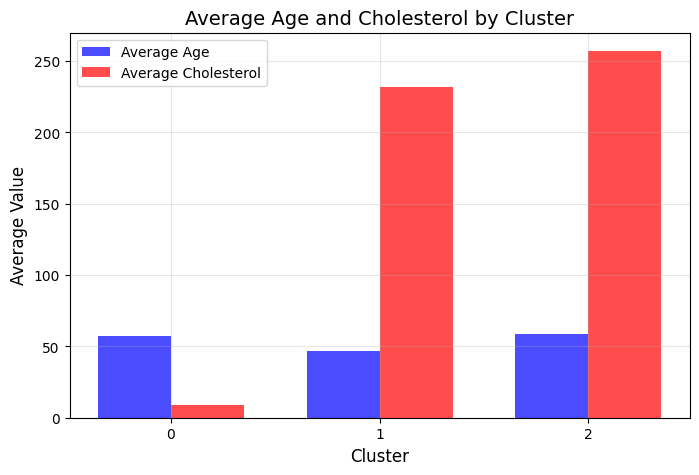

In [250]:

# Plot 2: Cluster Statistics
cluster_stats = df.groupby('Cluster')[['age', 'chol']].mean()

plt.figure(figsize=(8, 5))
x = np.arange(len(cluster_stats))
width = 0.35

plt.bar(x - width/2, cluster_stats['age'], width, label='Average Age', color='blue', alpha=0.7)
plt.bar(x + width/2, cluster_stats['chol'], width, label='Average Cholesterol', color='red', alpha=0.7)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.title('Average Age and Cholesterol by Cluster', fontsize=14)
plt.xticks(x, cluster_stats.index)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



Cluster 0 (blue): these are outliers with cholesterol near 0 possibly incorrect/missing data
Cluster 1 (brown): Mostly younger patients with a wide range of cholesterol
Cluster 2 (light blue): Mostly older patients cholesterol values slightly lower than cluster 1.

there’s no clear linear trend between age and cholesterol which supports why the regression model performed poorly 

**Pattren**
**CLUSTERING INSIGHTS**
dentified 3 distinct patient groups based on clinical features
Cluster 0: Older patients (57 years) with low cholesterol (possibly data error or missing data)
Cluster 1: Younger patients (47 years) with moderately high cholesterol
Cluster 2: Older patients (59 years) with the highest cholesterol levels
Shows a general trend where higher age relates to higher cholesterol except Cluster 0 which may have data limitation

**CLUSTERING INSIGHTS**

Patterns Found in Clusters:

Cluster 0 (169 patients):
  • Average age: 57.3 years
  • Average cholesterol: 9.1 mg/dL
  → Mixed risk profile

Cluster 1 (391 patients):
  • Average age: 46.8 years
  • Average cholesterol: 231.9 mg/dL
  → Young patients with normal cholesterol

Cluster 2 (359 patients):
  • Average age: 59.0 years
  • Average cholesterol: 257.1 mg/dL
  → Mixed risk profile

Key Finding: Patients naturally group by age and cholesterol levels

**REGGRESION**

C:\Users\rahma\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


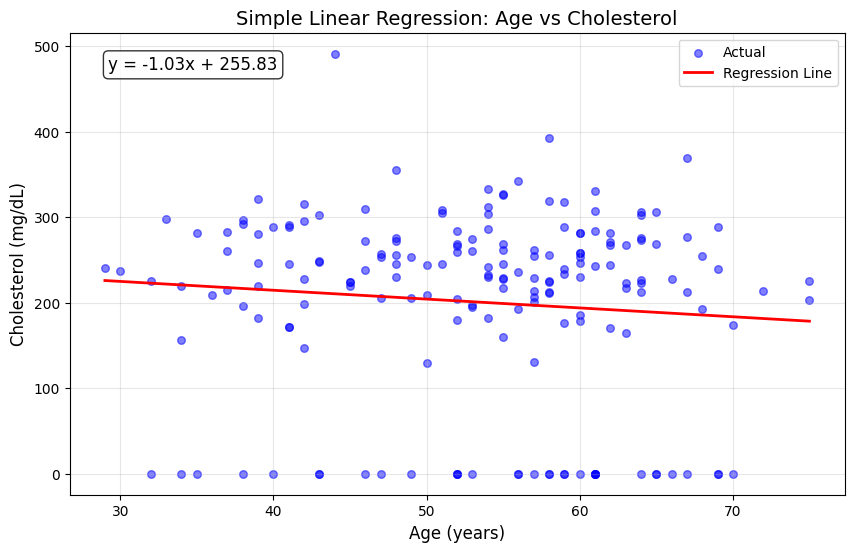

In [86]:
# Plot 1: Simple Regression Line
X_test=X_test_s
y_test= y_test_s
model=simple_lr
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.5, s=30, color='blue', label='Actual')

# Create line for regression
x_line = np.array([[X_test.min().iloc[0]], [X_test.max().iloc[0]]])
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Cholesterol (mg/dL)', fontsize=12)
plt.title('Simple Linear Regression: Age vs Cholesterol', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Add equation
equation = f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}'
plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()


the plot shows a simple linear regression between Age and Cholesterol levels the regression line equation is:
y = -1.03x + 255.83
interpretation:
the coefficient (-1.03) indicates a very slight negative relationship between age and cholesterol meaning cholesterol tends to decrease a bit as age increases
the intercept (255.83) is the predicted cholesterol when age is zero (theoretical value).
the points are quite scattered around the line indicating a weak linear relationship supported by the low R² score (0.0046 from your previous info)
there are many data points at zero cholesterol likely outliers or missing values affecting the model

this means age alone is a poor predictor of cholesterol in this dataset

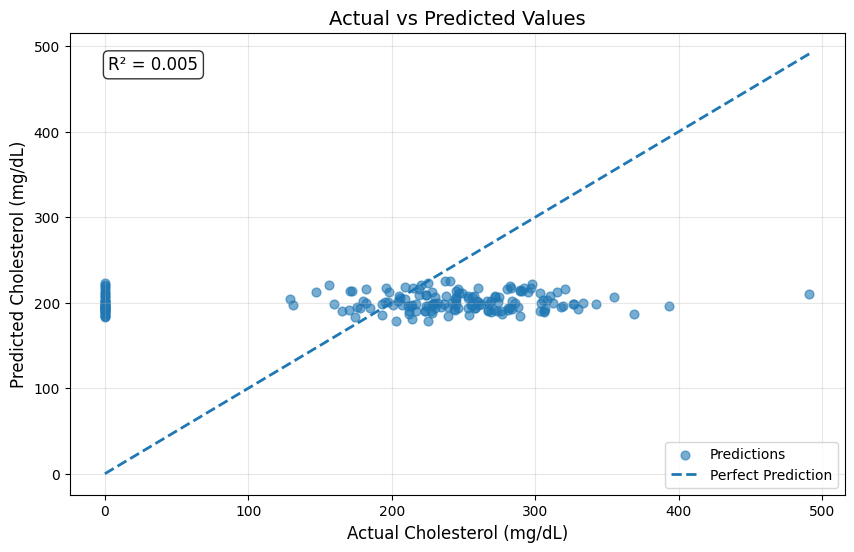

In [88]:
# Plot 2: Actual vs Predicted (Corrected)
plt.figure(figsize=(10, 6))

plt.scatter(y_test_s, y_pred_s, alpha=0.6, s=40, label='Predictions')

# Perfect prediction line
plt.plot(
    [y_test_s.min(), y_test_s.max()],
    [y_test_s.min(), y_test_s.max()],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel('Actual Cholesterol (mg/dL)', fontsize=12)
plt.ylabel('Predicted Cholesterol (mg/dL)', fontsize=12)
plt.title('Actual vs Predicted Values', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² score
r2 = r2_score(y_test_s, y_pred_s)
plt.text(
    0.05, 0.95,
    f'R² = {r2:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.show()


the points are mostly clustered horizontally around predicted values near 200 mg/dL regardless of the actual cholesterol values indicating the model predicts a narrow range of cholesterol values
the low R² value (0.005) means the model explains almost none of the variability in cholesterol
Predictions are poor and far from the perfect prediction line, confirming that age is not a strong predictor of cholesterol in this data

Overall the model has very limited predictive power for cholesterol based on age alone

**patterns and insights from each method.(regression)**
weak Relationship:the R² value (0.005) shows that age explains almost none of the variation in cholesterol levels
Negative Coefficient:the coefficient (-1.03) suggests cholesterol slightly decreases with age but the effect is minimal and not meaningful
High Errors:RMSE (~108) and MAE (~84) indicate large prediction errors meaning the model isn’t accurate
flat Predictions:the model tends to predict cholesterol around 200 for most ages showing poor fit and lack of responsiveness to actual data variation
rsiduals Spread: the residual plot shows no clear pattern but wide spread supporting that a linear model doesn’t capture the relationship well

age alone is not a good predictor of cholesterol in this dataset the relationship is weak and likely non-linear or influenced by other factors

**Summary of Findings**

Clustering was more useful in this case because it grouped similar patients and showed patterns that regression couldn’t the regression model was too simple and only used one feature (age) which is not enough to predict cholesterol accurately a better model would need more variables like diet activity or genetics

ror clustering the K-Means algorithm worked best it identified three meaningful clusters that clearly separated patients based on features like age and cholesterol

Cluster 1 mostly included younger individuals with moderate cholesterol levels Cluster 2 had older individuals with the highest cholesterol and Cluster 0 contained values with very low cholesterol possibly due to missing data the clusters were well-separated in both the PCA plot and the scatter plots showing that K-Means effectively grouped the patients based on similarities this helped uncover hidden patterns that couldn’t be seen from simple statistics

for regression i applied simple linear regression to predict cholesterol using age the model had a very low R² score of 0.005 indicating almost no relationship the regression line was nearly flat and the residuals were widely spread meaning the model wasn’t able to make accurate predictionn the model also had high error values (RMSE and MAE) which further proved that age alone is not a good predictor for cholesterol

Strengths and Limitations:
Clustering gave more meaningful insights than regression it helped discover subgroups of patients with similar traits which could be useful in healthcare decisions. However clustering doesn’t predict outcomes like regression does on the other hand regression was too limited because it only used one variable a better regression model would need more features to improve prediction (the missing data caused the avg of cluster 0 to be unrealistis which affected both regression and clustering reasult)